In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction

In [3]:
%load_ext autoreload
%autoreload 2

In [6]:
import scanpy as sc 
path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/0_1/adata_intermediate.h5ad"
adata = sc.read_h5ad(path)

/home/mila/m/myriam.lizotte/envs/env_rfmali/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [8]:
for method in adata.obsm.keys():
    print(method)
    print(adata.obsm[method].shape)

FoSTA_PHATE_t2
(5851, 2)
Harmony
(5851, 30)
KEMAlin
(5851, 2)
KEMArbf
(5851, 2)
MALI
(5851, 2)
Pamona
(5851, 30)
RFMALI_PHATE_t2
(5851, 2)
Scanorama
(5851, 2)
Unintegrated
(5851, 30)
X_pca
(5851, 30)
scANVI
(5851, 2)
scVI
(5851, 2)


In [8]:
base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
mali_path = "/home/mila/m/myriam.lizotte/MALI"
scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"


# save_name = f"real_batches_no_masking" #dataset}".format(dataset = dataset_name)
save_name = f"real_batches_immune" 
# save_name = f"real_batches_no_pca_no_hvg" 
# save_name = f"real_batches_with_pca_no_hvg" 
jobid = 9186981
save_path = f"{scratch_path}/results/{save_name}/{jobid}"


# batches = ["1","2","3","4","5","6", "A1", "A2", "A3", "A4", "A5", "A6", "B1", "B2", "B3", "B4"]
batches = [i for i in range(10)]

create a new summary df based on aggregating the dfs in the n_comp subfolders (only needs to be ran once)

In [9]:

all_results_df = pd.DataFrame()
for i1, batch1 in enumerate(batches):
    for i2, batch2 in enumerate(batches):
        if i1 >= i2:
            continue
    
        save_path_subfolder = f"{save_path}/{batch1}_{batch2}"
        try:
            df = pd.read_csv(f"{save_path_subfolder}/real_batches_results.csv")
        except FileNotFoundError:
            df = pd.DataFrame()
            print(f"File not found: {save_path_subfolder}/real_batches_results.csv")

        df["batch1"] = batch1
        df["batch2"] = batch2
        all_results_df = pd.concat([all_results_df, df], ignore_index=True)
                
all_results_df    
all_results_df.to_csv(f"{save_path}/real_batches_results.csv", index=False)
                

File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/0_4/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/1_4/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/2_4/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/3_4/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/3_5/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/3_6/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/3_7/real_batches_results.csv
File not found: /home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/9186981/3_8/real_batches_results.csv


# Real batches data

In [10]:
# exp = "real_batches_20pct_masking"
# exp = "real_batches_no_masking"
# results_path = f"/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/{exp}"

results_path=save_path

# load results
results_df = pd.read_csv(f"{results_path}/real_batches_results.csv")


metric_type = results_df.loc[results_df["method"] == "Metric Type"]
metric_type = metric_type.drop(columns=['method']).drop_duplicates()
results_df = results_df.loc[results_df["method"] != "Metric Type"]


# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['method', 'batch1', 'batch2'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')


# results_df = results_df.drop(0, axis = 0) # remove one run from debugging
# results_df.drop_duplicates(subset=['method'], keep='last', inplace=True)


# delete rows where n_components is NA
results_df = results_df.loc[~results_df["n_components"].isna()]


# remove n_components in the model column (it was just used to not overwrite adata, and it's already another column)
results_df["method"] = results_df["method"].str.replace(r'_\d+_components', '', regex=True)

In [11]:
# rename FOSTA PHATE t2 to FoSTA
results_df["method"] = results_df["method"].replace({"FoSTA_PHATE_t2": "FoSTA"})
results_df["method"] = results_df["method"].replace({"RFMALI_PHATE_t2": "RFMALI"})

methods_to_remove= ["RFMALI", "LIGER"]
results_df = results_df[~results_df["method"].isin(methods_to_remove)]

In [12]:
results_df

,n_components,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,...,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,trajectory_score,time,memory,batch1,batch2
0,2.0,Unintegrated,0.678164,0.815470,0.588992,0.748264,0.513713,0.590344,0.999479,0.707836,...,0.000000,0.384678,0.704918,0.576822,NaN,NaN,NaN,NaN,0,1
1,2.0,FoSTA,0.584226,0.727990,0.478702,0.780936,0.732918,0.744142,1.000000,0.333467,...,0.967473,0.602061,0.721274,0.673589,0.606039,0.526062,84.688411,769.412887,0,1
3,2.0,MALI,0.916870,0.591757,0.284244,0.596098,0.328875,0.440907,0.964575,0.183489,...,0.926620,0.561075,0.589047,0.577858,0.099613,0.380162,21.376946,1813.028049,0,1
4,2.0,Scanorama,0.601046,0.576562,0.345590,0.596604,0.374897,0.530457,0.946138,0.525895,...,0.000000,0.486493,0.567328,0.534994,0.345028,0.534749,2.312563,277.637123,0,1
5,2.0,Harmony,0.673976,0.806199,0.574579,0.750663,0.498035,0.592437,0.998301,0.803514,...,0.199884,0.650660,0.699170,0.679766,0.869993,0.866171,1.904404,84.700244,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,2.0,scVI,0.728755,0.636485,0.319801,0.645796,0.446313,0.549097,0.993128,0.398854,...,0.898243,0.460620,0.617054,0.554480,0.737251,0.466476,230.137314,91.013462,2,9
499,2.0,scANVI,0.832079,0.762076,0.438994,0.745370,0.529133,0.644339,1.000000,0.237897,...,0.860049,0.451808,0.707427,0.605179,0.524452,0.568399,240.558401,64.876033,2,9
500,2.0,Pamona,0.615750,0.616929,0.376006,0.620423,0.546109,0.493722,0.983181,0.533602,...,0.992375,0.459341,0.607446,0.548204,0.335152,0.688649,221.507946,1342.127710,2,9
501,2.0,KEMArbf,0.453766,0.676748,0.404586,0.658194,0.431941,0.585784,0.981943,0.571419,...,0.942141,0.589731,0.598995,0.595289,0.957059,0.399590,2.490278,8.923294,2,9


# make plots

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


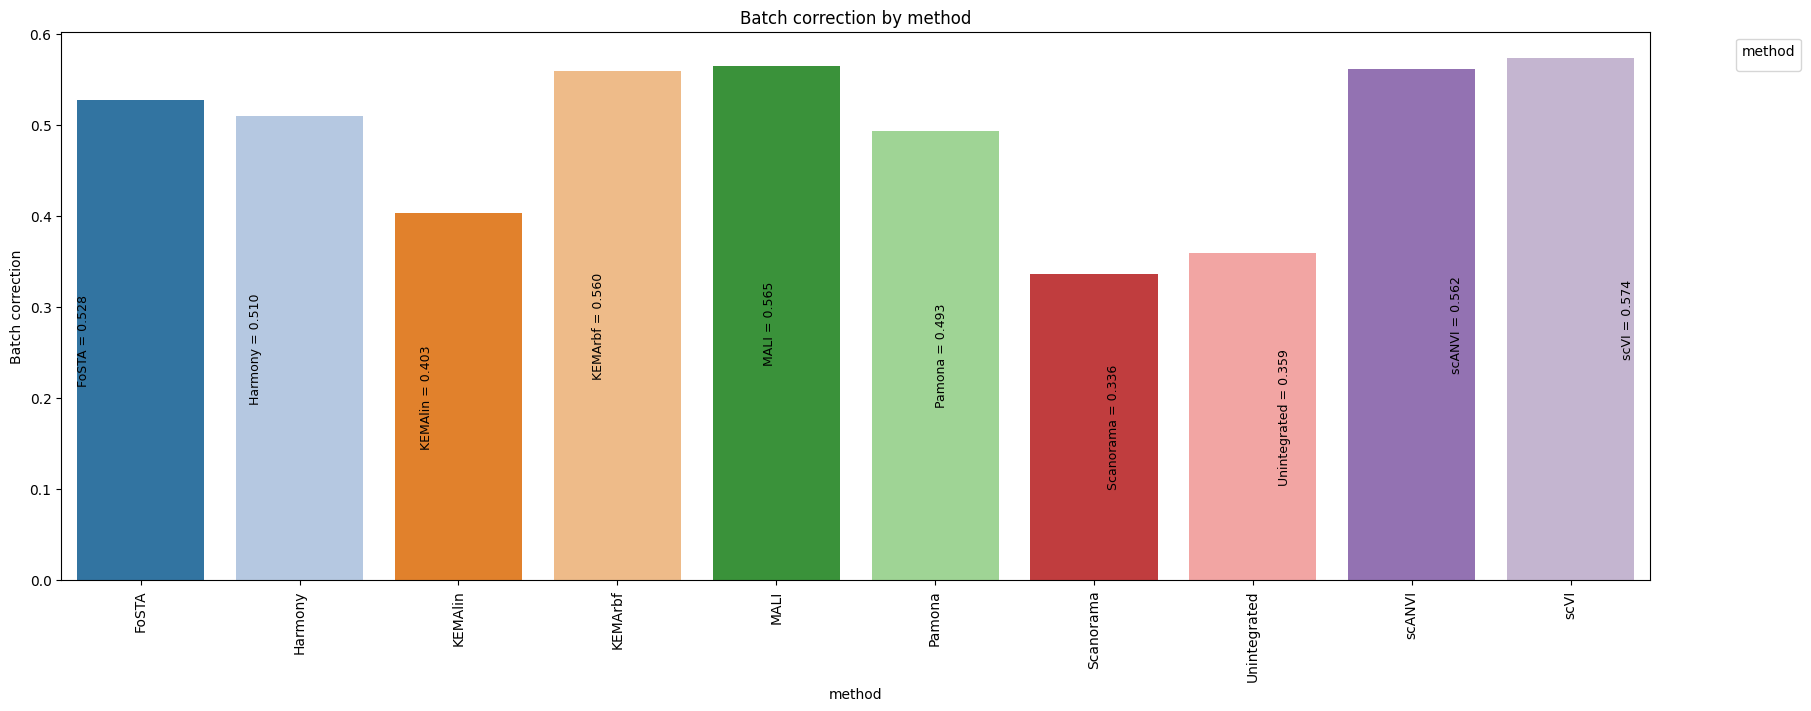

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


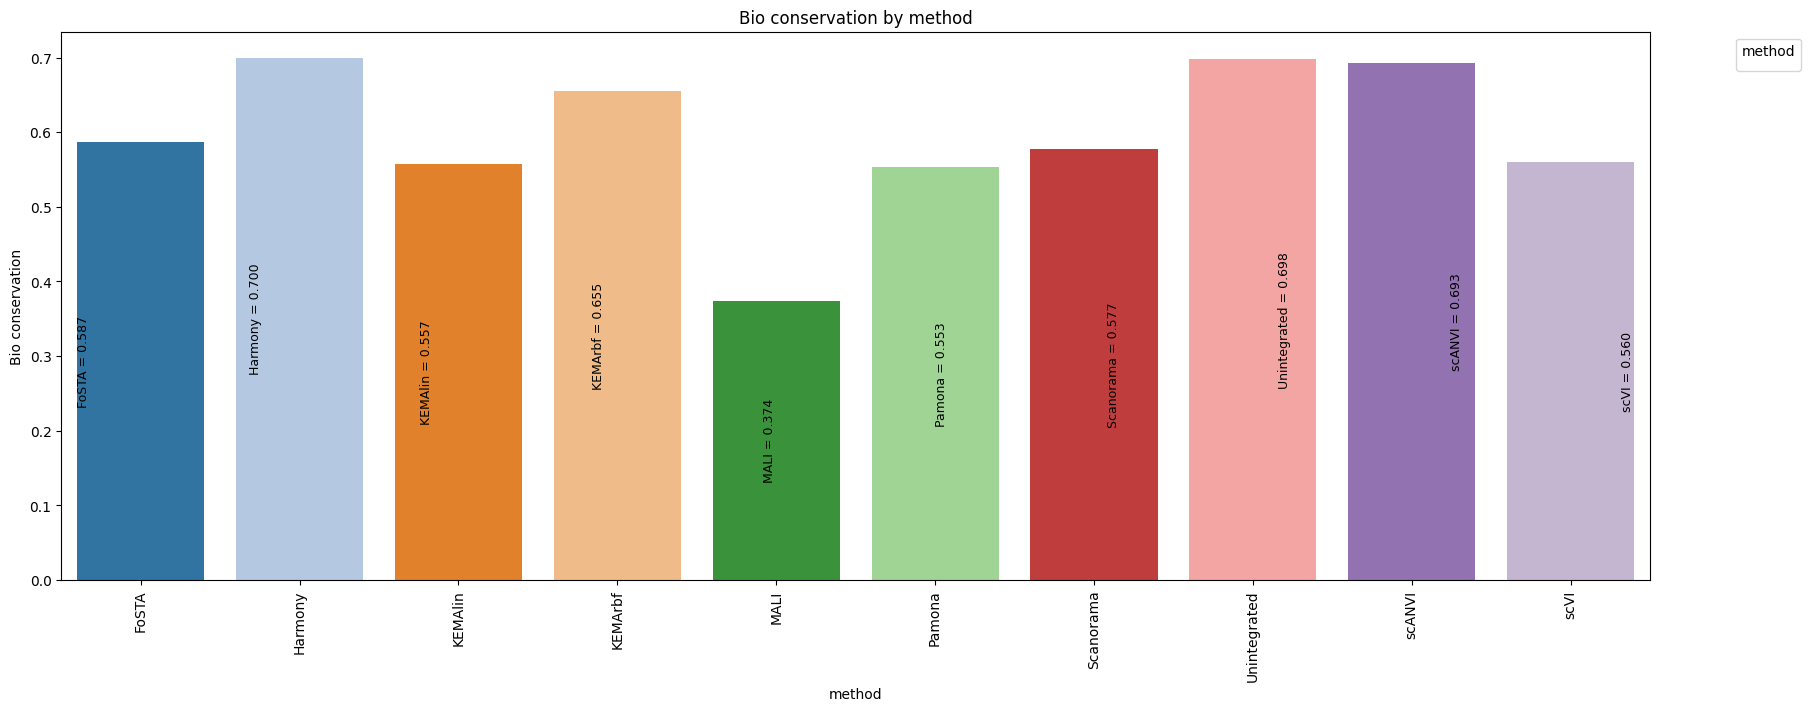

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


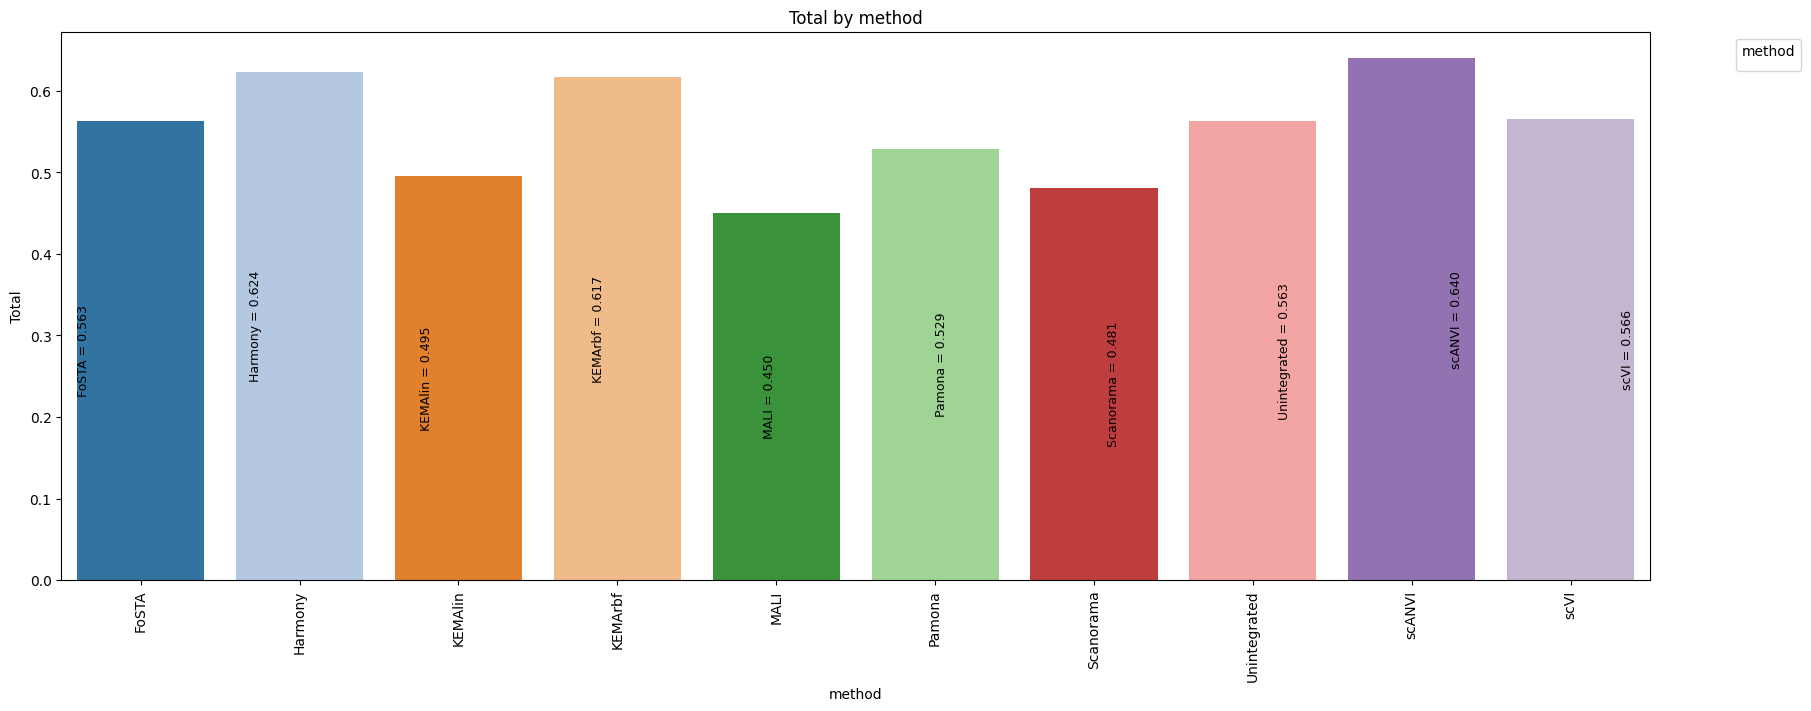

In [31]:
plot_metric_grouped_by(results_df, groupby_cols=["method"])

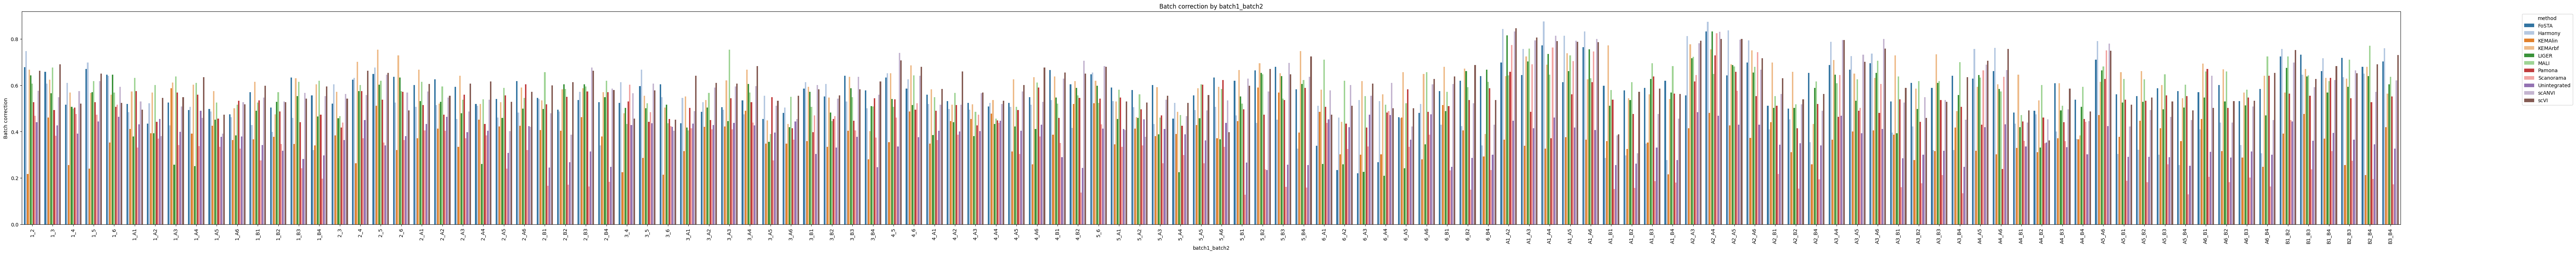

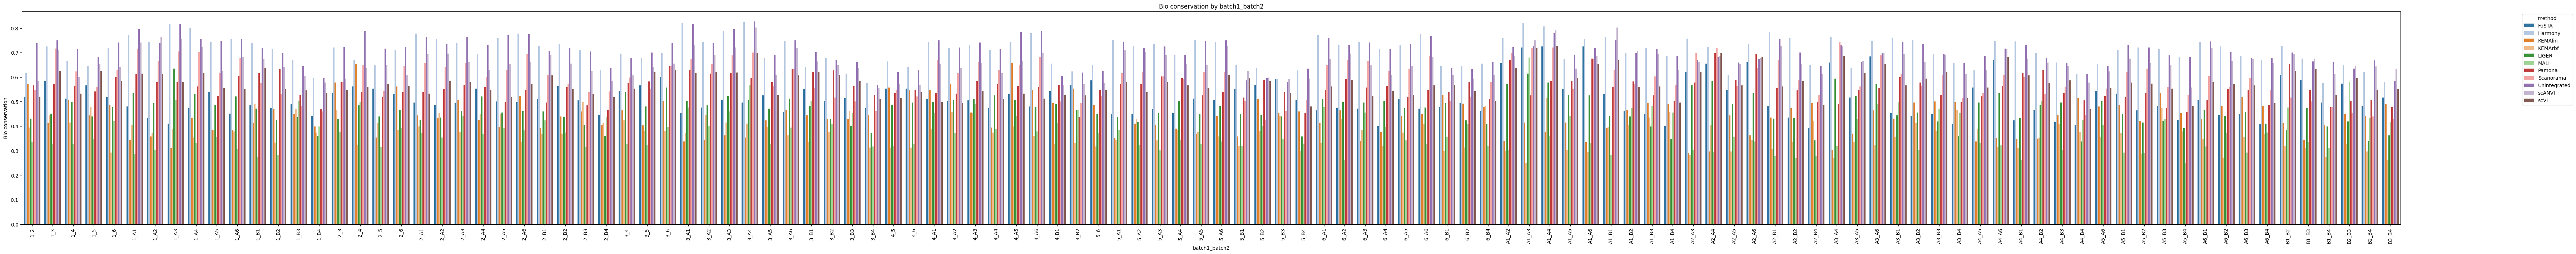

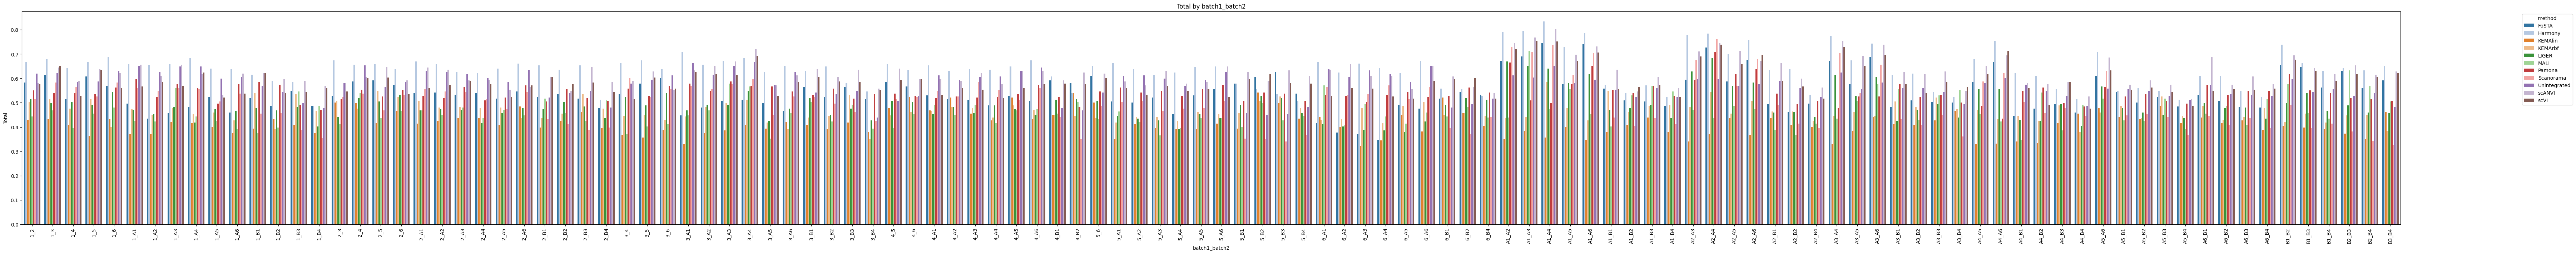

In [12]:
plot_metric_grouped_by(results_df, groupby_cols=["batch1_batch2", "method"], annotate=False, fig_len_factor=4)

In [39]:
results_df["batch1_batch2"] = results_df["batch1"] + "_" + results_df["batch2"]

In [40]:
len(results_df["batch1_batch2"].unique())

120

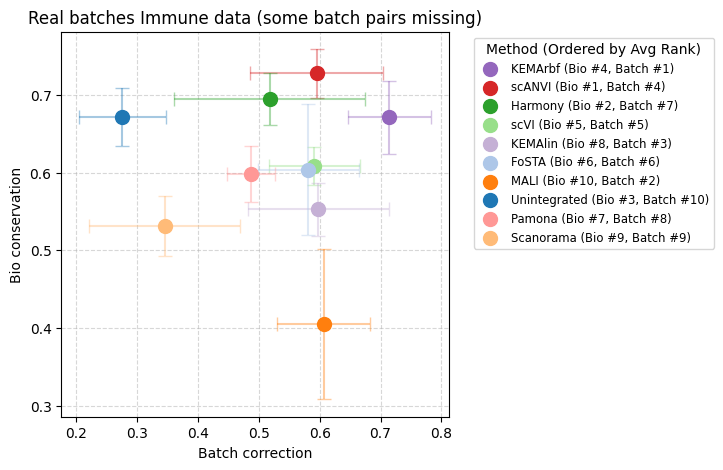

In [14]:
plot_bio_vs_batch_correction(results_df, title= "Real batches Immune data (some batch pairs missing)")

# All pairs including batch 3

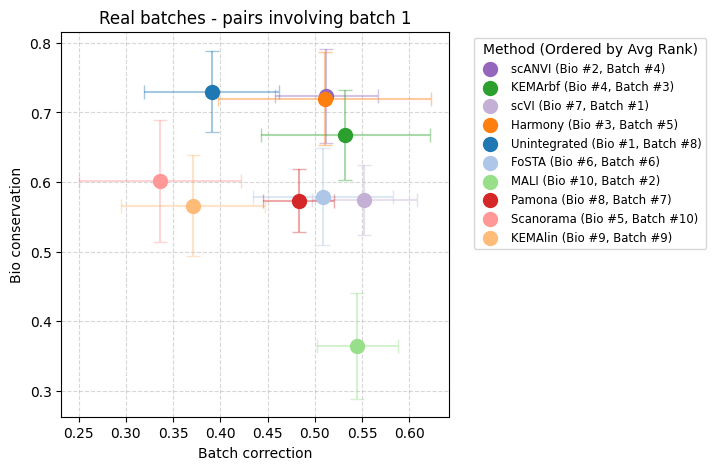

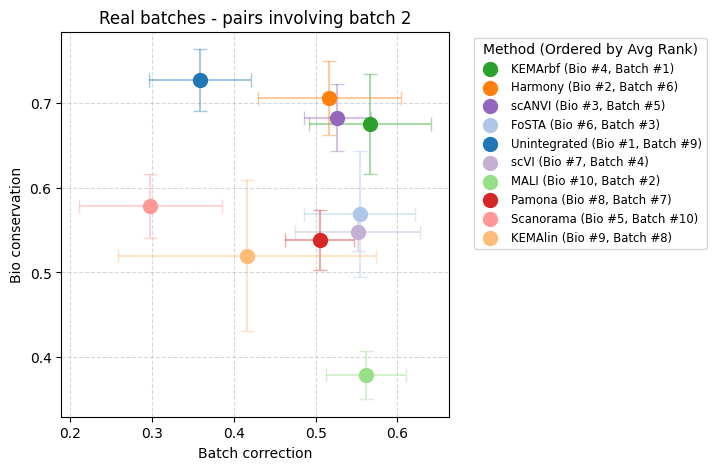

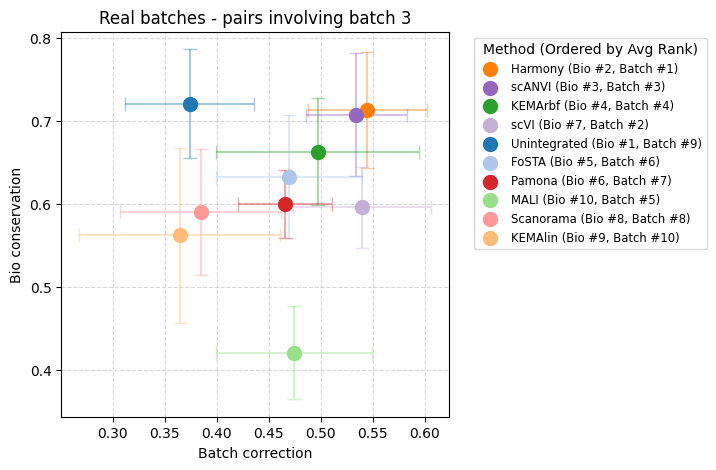

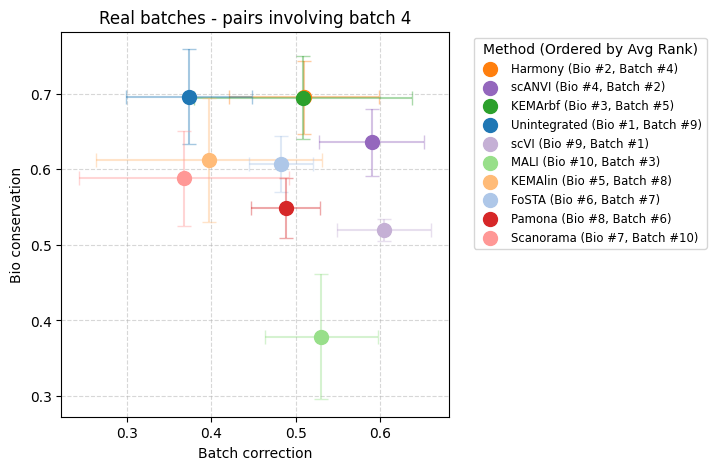

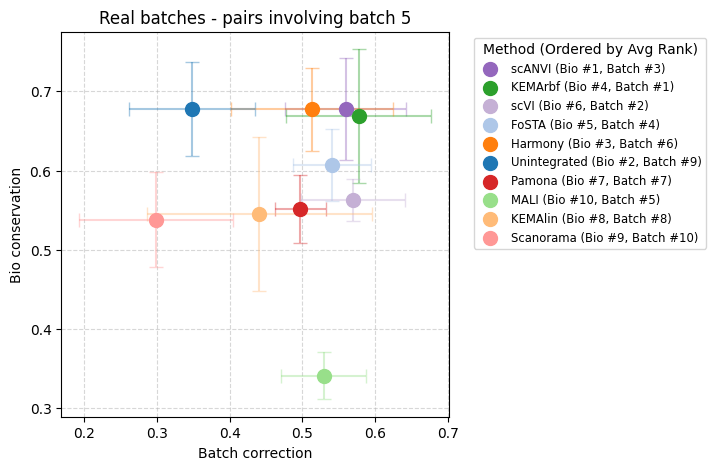

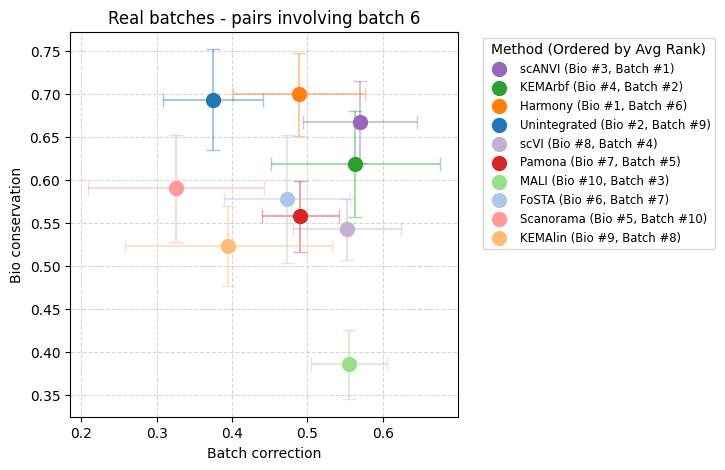

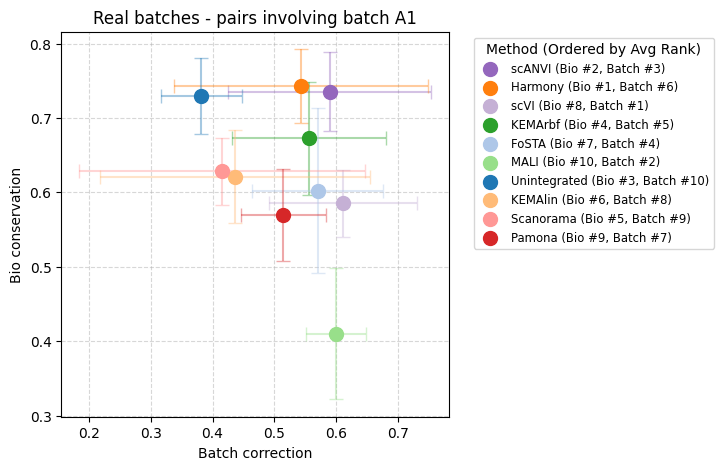

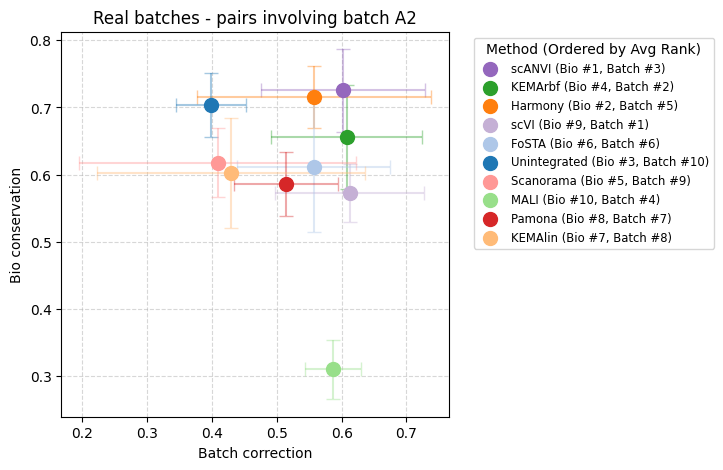

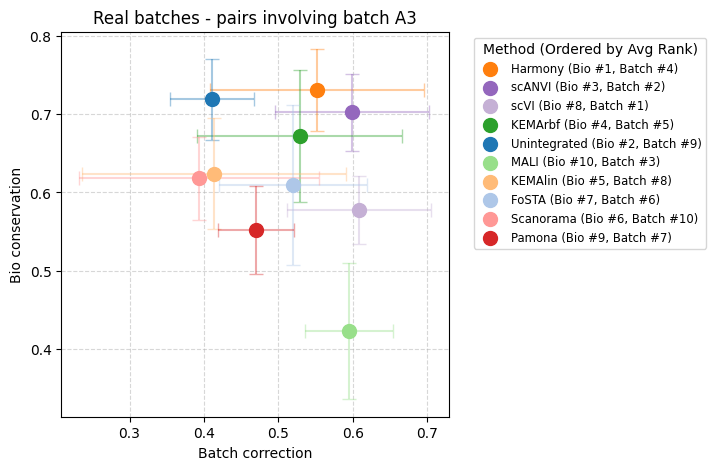

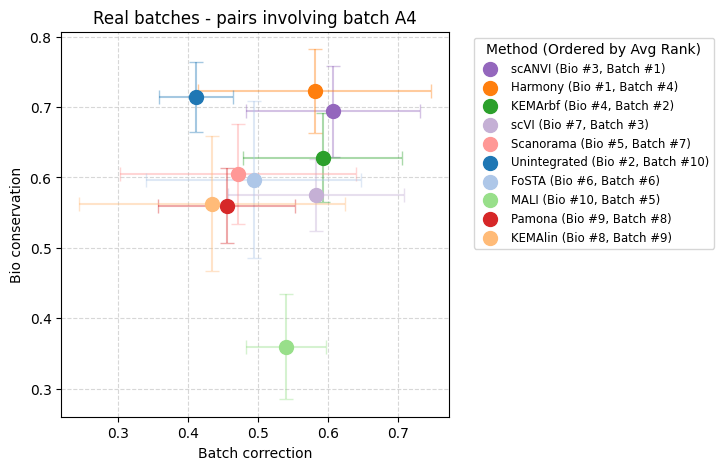

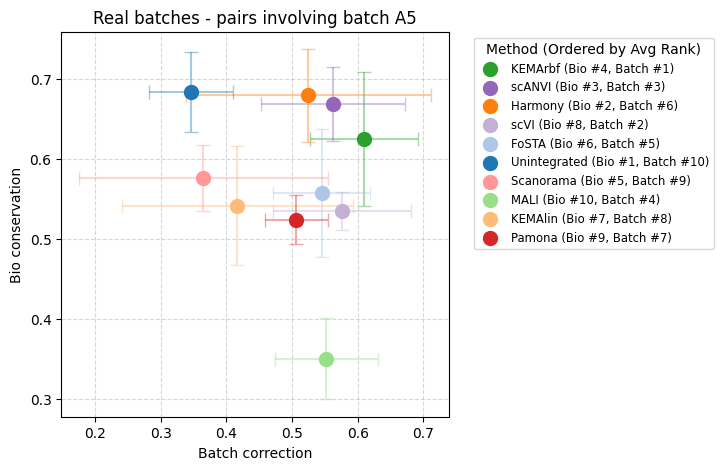

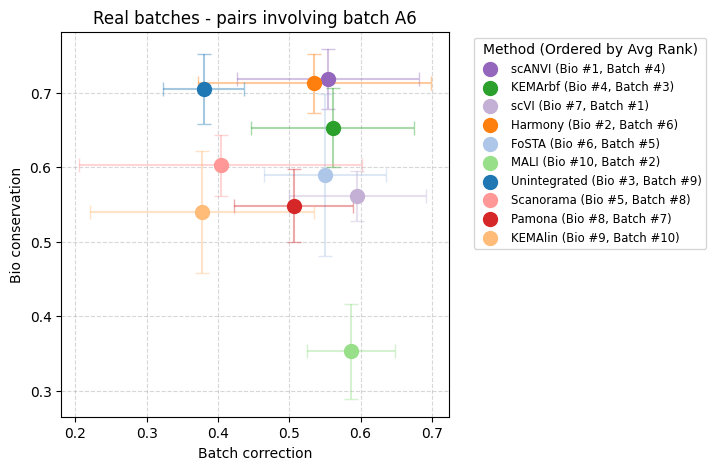

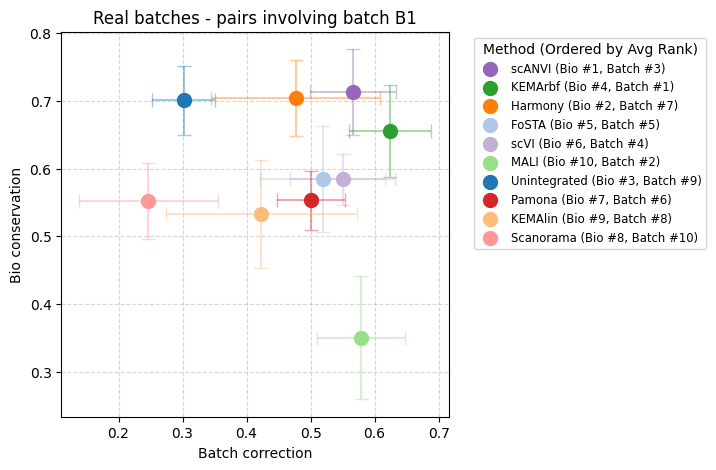

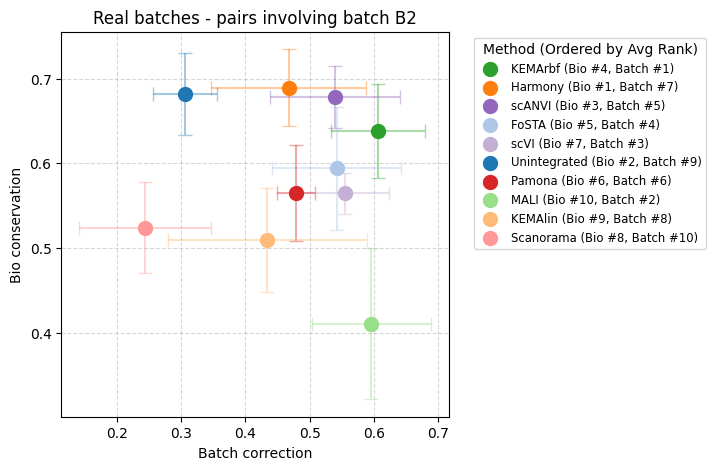

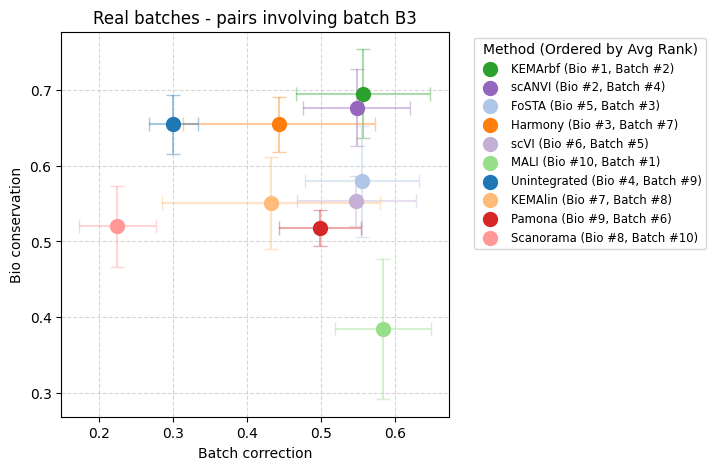

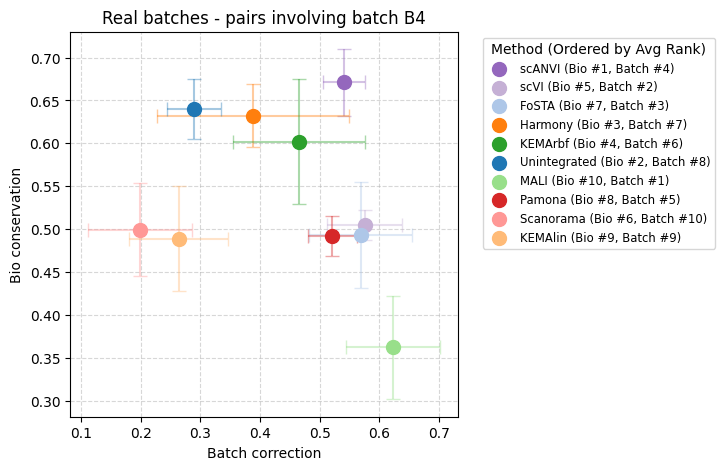

In [25]:

for reference_batch in batches:
    
    results_pairs_involving_ref = results_df[results_df["batch1"].str.startswith(reference_batch) | results_df["batch2"].str.startswith(reference_batch)]
    plot_bio_vs_batch_correction(results_pairs_involving_ref, title= f"Real batches - pairs involving batch {reference_batch}")

In [21]:
results_pairs_involving_3.groupby(["batch1","batch2"])[["Bio conservation", "Batch correction", "Total"]].mean()

Bio conservation  Batch correction     Total
batch1 batch2                                              
1      3               0.664669          0.504500  0.600601
2      3               0.617164          0.427210  0.541183
3      4               0.609643          0.454711  0.547670
       5               0.600591          0.511875  0.565105
       6               0.656518          0.431154  0.566373
       A1              0.673467          0.459919  0.588048
       A2              0.649461          0.468057  0.576900
       A3              0.667102          0.493513  0.597666
       A4              0.697428          0.511772  0.623166
       A5              0.563761          0.445089  0.516292
       A6              0.615964          0.403704  0.531060
       B1              0.625629          0.492471  0.572366
       B2              0.596615          0.472371  0.546917
       B3              0.579989          0.473799  0.537513
       B4              0.497863          0.424007  0.468320

In [12]:
results_df

,n_components,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,batch1,batch2
0,2,Unintegrated,0.689139,0.843168,0.759863,0.713380,0.410441,0.617249,1.000000,0.585479,2.384186e-07,0.641104,0.868665,0.000000,0.419050,0.719034,0.599041,1,2
1,2,FoSTA,0.532583,0.632955,0.360952,0.691445,0.616973,0.707631,0.987735,0.306392,4.797320e-01,0.845539,0.839885,0.828369,0.659984,0.647182,0.652303,1,2
2,2,Harmony,0.669874,0.708743,0.530571,0.622387,0.308961,0.571153,0.971282,0.700165,4.678814e-01,0.773406,0.846555,0.772424,0.712086,0.626139,0.660518,1,2
3,2,KEMAlin,0.490222,0.595553,0.343460,0.604713,0.351938,0.617881,0.981966,0.291417,1.032782e-02,0.310134,0.807586,0.682376,0.420368,0.569390,0.509782,1,2
4,2,KEMArbf,0.686620,0.531760,0.231713,0.595033,0.309973,0.602709,0.964712,0.416920,5.242755e-01,0.827984,0.734138,0.982310,0.697125,0.560360,0.615066,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3091,2,MALI,0.470747,0.388133,0.140413,0.409919,0.178002,0.388435,0.901030,0.448973,9.390534e-01,0.421394,0.561830,0.999998,0.674249,0.410954,0.516272,B3,B4
3092,2,Pamona,0.520693,0.449619,0.184148,0.458442,0.304784,0.528182,0.972217,0.582628,1.794038e-01,0.175149,0.635093,0.997556,0.513966,0.488298,0.498565,B3,B4
3094,2,Scanorama,0.434496,0.357545,0.236965,0.355323,0.230803,0.516858,0.890074,0.172511,1.810312e-03,0.179286,0.454014,0.000000,0.161524,0.431723,0.323644,B3,B4
3095,2,scANVI,0.684519,0.649613,0.417236,0.615514,0.407094,0.598170,0.996211,0.496482,3.376510e-01,0.625367,0.870617,0.740651,0.614153,0.624051,0.620092,B3,B4


# look for the best performance

In [59]:
best_idx_total = results_df.loc[results_df["method"] == "FoSTA", "Total"].idxmax()
best_idx_bio = results_df.loc[results_df["method"] == "FoSTA", "Bio conservation"].idxmax()
best_idx_batch = results_df.loc[results_df["method"] == "FoSTA", "Batch correction"].idxmax()

best_pair_total = results_df.loc[best_idx_total]["batch1_batch2"]
best_pair_bio = results_df.loc[best_idx_bio]["batch1_batch2"]
best_pair_batch = results_df.loc[best_idx_batch]["batch1_batch2"]

total_pair_df = results_df.loc[results_df["batch1_batch2"] == best_pair_total]
bio_pair_df = results_df.loc[results_df["batch1_batch2"] == best_pair_bio]
batch_pair_df = results_df.loc[results_df["batch1_batch2"] == best_pair_batch]

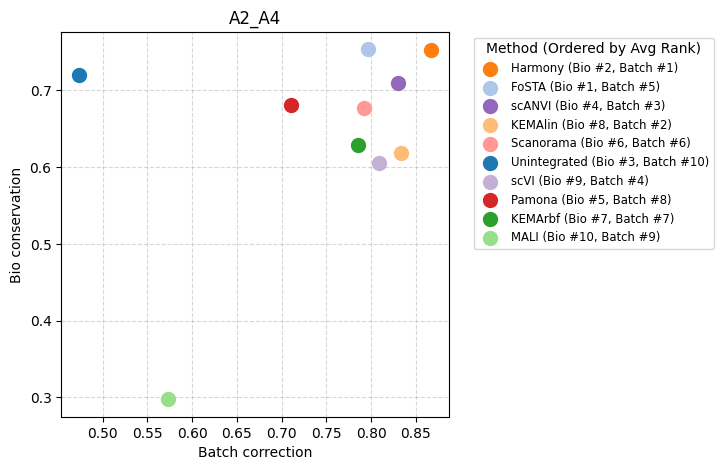

In [65]:
plot_bio_vs_batch_correction(total_pair_df, title = best_pair_total)

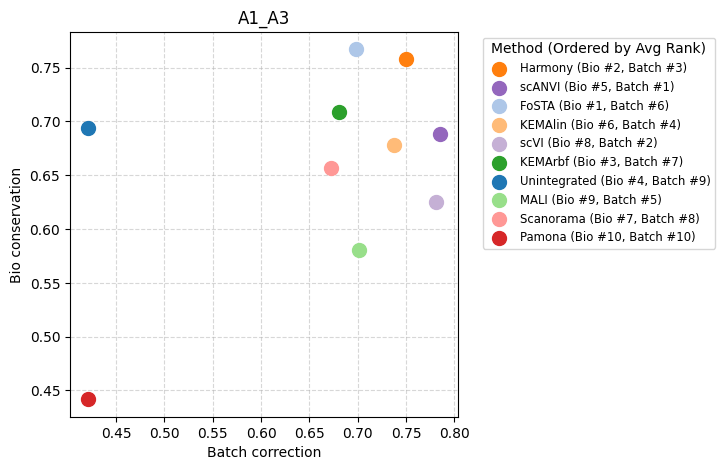

In [66]:
plot_bio_vs_batch_correction(bio_pair_df, title = best_pair_bio)

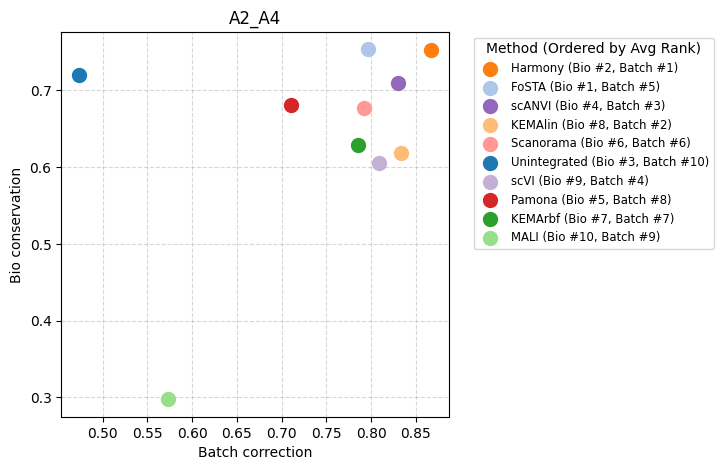

In [67]:
plot_bio_vs_batch_correction(batch_pair_df, title = best_pair_batch)

# only consider batches within the same set

In [17]:
results_df["batch1"] = results_df["batch1"].astype(str)
results_df["batch2"] = results_df["batch2"].astype(str)

In [18]:
def get_set_of_batch(batch):
    if batch.startswith("A"):
        return "A"
    elif batch.startswith("B"):
        return "B"
    else:
        return "0"
    
results_df["same_batch_set"] = (results_df["batch1"].apply(get_set_of_batch) == results_df["batch2"].apply(get_set_of_batch))

In [19]:
same_batch_results_df = results_df.loc[results_df["same_batch_set"] == True]

In [6]:
plot_bio_vs_batch_correction(same_batch_results_df)

NameError: name 'same_batch_results_df' is not defined